In [52]:
import numpy as np
import pandas as pd

%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "font.size": 12,
    })


detections_narrow_ET = pd.read_csv("./detection_output/narrow_ET.dat", sep="    ")

/tmp/ipykernel_25366/731443383.py:14: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  detections_narrow_ET = pd.read_csv("./detection_output/narrow_ET.dat", sep="    ")


In [60]:
np.sum(np.sum(detections_narrow_ET[["lssti", "lsstg", "ztfg", "ztfi", "ps1::g", "ps1::i", "ultrasat_custom"]], axis=1) >=2)

np.int64(523)

In [63]:
np.sum(detections_narrow_ET["telt_vr"]) / (0.5*365)

np.float64(1.727638254693049)

Text(0.5, 0, '$z$')

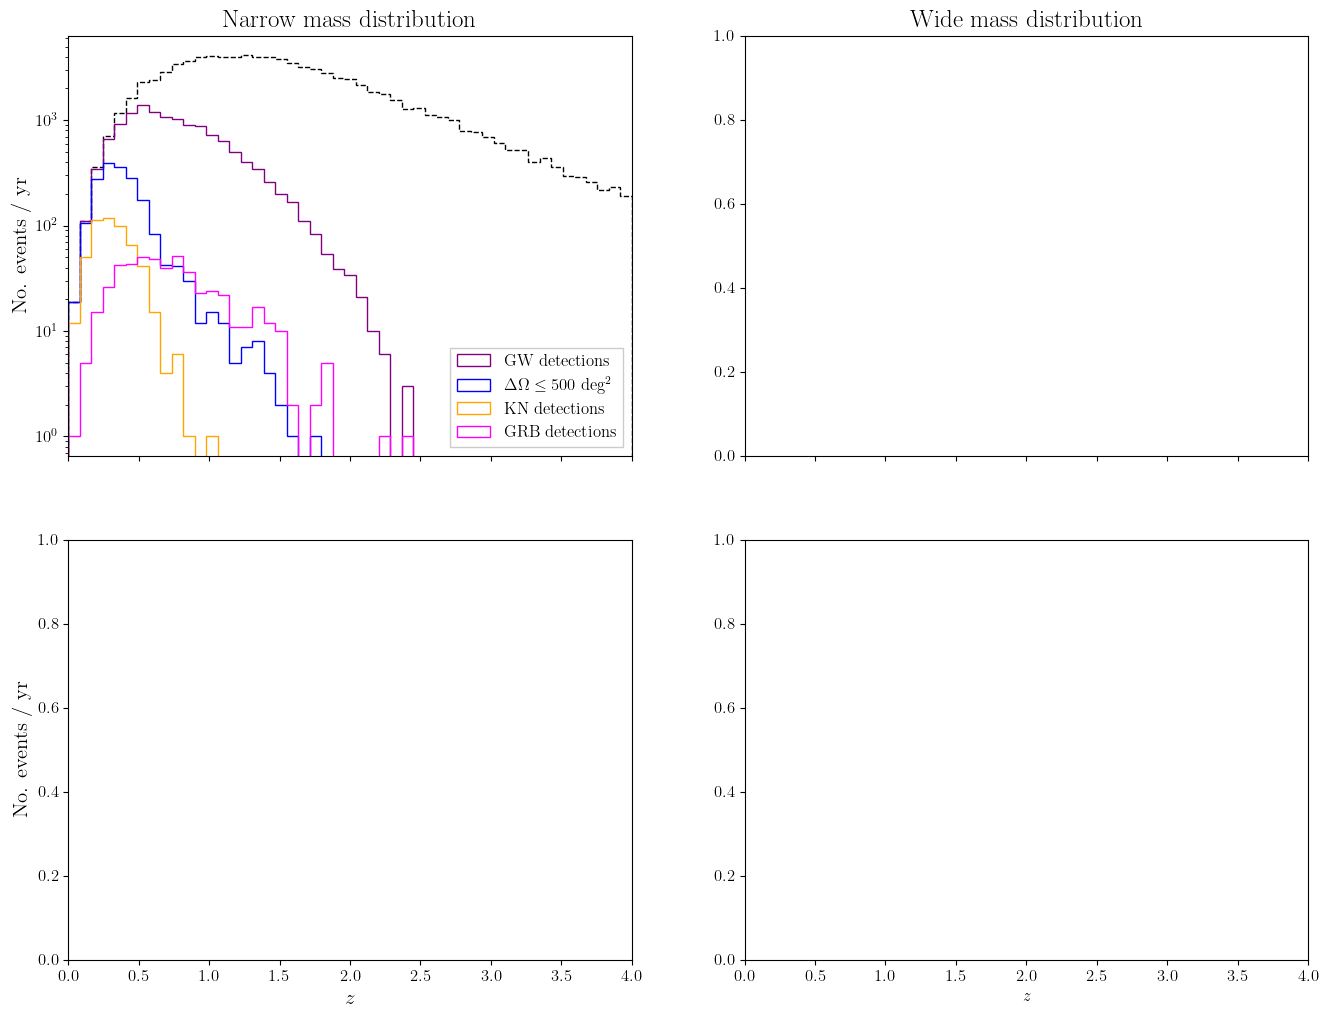

In [72]:
def plot_detections(ax, df):
    
    gw_detected = df["gw_detected"].astype(bool)
    grb_detected = df["grb_detected"].astype(bool)
    kn_detected = np.sum(df[["lsstg", "lssti", "ztfg", "ztfi", "ps1::i", "ps1::g", "ultrasat_custom"]], axis=1) >= 2
    #ztf_detected = (df["ztfg"] + df["ztfi"]) >= 2
    #pstarrs_detected = (df["ps1::i"] + df["ps1::g"]) >= 2
    #ultrasat_detected = (df["ultrasat_custom"]) >= 1
    sky_loc = df["DeltaOmega"] <= 500.

    ax.hist(df["redshift"], bins=np.linspace(0, 4, 50), histtype = "step", color="black", linestyle="dashed")
    ax.hist(df["redshift"][gw_detected], bins=np.linspace(0, 4, 50), histtype="step", color="purple", label="GW detections")
    ax.hist(df["redshift"][sky_loc], bins=np.linspace(0, 4, 50), histtype="step", color="blue", label="$\\Delta\\Omega \\leq 500$ deg$^2$")
    ax.hist(df["redshift"][kn_detected], bins=np.linspace(0, 4, 50), histtype="step", color="orange", label="KN detections")
    #ax.hist(df["redshift"][ztf_detected], bins=np.linspace(0, 4, 50), histtype="step", color="red")
    #ax.hist(df["redshift"][ultrasat_detected], bins=np.linspace(0, 4, 50), histtype="step", color="salmon")
    #ax.hist(df["redshift"][pstarrs_detected], bins=np.linspace(0, 4, 50), histtype="step", color="yellow")
    ax.hist(df["redshift"][grb_detected], bins=np.linspace(0, 4, 50), histtype="step", color="magenta", label="GRB detections")

    ax.set_yscale("log")



fig, ax = plt.subplots(2, 2, figsize= (16, 12), sharex=True)

ax[0,0].set_title("Narrow mass distribution", fontsize=18)
ax[0,0].set_ylabel("No. events / yr", fontsize=15)
plot_detections(ax[0,0], detections_narrow_ET)
ax[0,0].legend(framealpha=1.0, fancybox=False, fontsize=12)



#ax[1,0].set_ylabel("ET + CE", fontsize=18)
ax[1,0].set_ylabel("No. events / yr", fontsize=15)
ax[1,0].set_xlim(0, 4)
ax[1,0].set_xlabel("$z$", fontsize=15)

ax[0,1].set_title("Wide mass distribution", fontsize=18)

ax[1,1].set_xlim(0, 4)
ax[1,1].set_xlabel("$z$")


In [33]:
np.sum(detectable_KN_narrow & (fim_narrow_ET_CE[:, 1]< 100))

np.int64(6524)

In [34]:
np.sum(detectable_KN_wide & (fim_wide_ET_CE[:, 1]< 100))

np.int64(2267)